In [63]:
import pandas as pd
dt = pd.read_csv('4.csv')

dt.head()

,Rank,Sourceid,Title,Type,Issn,SJR,SJR Best Quartile,H index,Total Docs. (2020),Total Docs. (3years),Total Refs.,Total Cites (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Country,Region,Publisher,Coverage,Categories
0,1,19900191906,Academy of Management Annals,journal,"19416520, 19416067","18,318",Q1,73,31,76,7077,1648,75,16.43,228.29,United States,Northern America,Academy of Management,2010-2020,Business and International Management (Q1); Or...
1,2,17500,Journal of Finance,journal,"00221082, 15406261","18,151",Q1,299,78,206,4002,1966,203,7.01,51.31,United Kingdom,Western Europe,Wiley-Blackwell Publishing Ltd,1946-2020,Accounting (Q1); Economics and Econometrics (Q...
2,3,16161,Review of Financial Studies,journal,"14657368, 08939454","12,800",Q1,190,120,334,6948,2565,334,6.23,57.90,United Kingdom,Western Europe,Oxford University Press,1996-2020,Accounting (Q1); Economics and Econometrics (Q...
3,4,24379,Journal of Financial Economics,journal,0304405X,"11,673",Q1,256,154,373,7975,3129,372,6.88,51.79,Netherlands,Western Europe,Elsevier,1974-2020,Accounting (Q1); Economics and Econometrics (Q...
4,5,20191,Academy of Management Journal,journal,14273,"11,193",Q1,318,68,261,6929,2839,260,9.13,101.90,United States,Northern America,Academy of Management,"1975-1987, 1989-2020",Business and International Management (Q1); Bu...


In [64]:
dt.isnull()

,Rank,Sourceid,Title,Type,Issn,SJR,SJR Best Quartile,H index,Total Docs. (2020),Total Docs. (3years),Total Refs.,Total Cites (3years),Citable Docs. (3years),Cites / Doc. (2years),Ref. / Doc.,Country,Region,Publisher,Coverage,Categories
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1403,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1404,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1405,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1406,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [65]:
dt.isnull().sum()

,0
Rank,0
Sourceid,0
Title,0
Type,0
Issn,0
SJR,0
SJR Best Quartile,0
H index,0
Total Docs. (2020),0
Total Docs. (3years),0


In [66]:
import numpy as np

def clean_dataset(dt):
    assert isinstance(dt, pd.DataFrame), "dt needs to be a pd.DataFrame"
    dt.dropna(inplace=True)
    indices_to_keep = ~dt.isin([np.nan, np.inf, -np.inf]).any(1)
    return dt[indices_to_keep].astype(np.float64)

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [68]:
#attribut selection
X = dt.iloc[:,[7, 8, 9, 10, 11, 12, 13, 14]].values
y = dt.iloc[:,6].values

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify=y, random_state=10)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [70]:
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)

In [71]:
#define cross-validation method to use
cv = KFold(n_splits=10, random_state=1, shuffle=True)

In [72]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier

In [73]:
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [74]:
Adanb = AdaBoostClassifier(estimator=nb, n_estimators=1000,
                               random_state=0)

Adanb.fit(X_train, y_train)
Adanb_preds = Adanb.predict(X_test)

In [75]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([('scaler', StandardScaler()), ('model', Adanb)])
result = model_selection.cross_val_score(pipe, X, y, cv=cv)

In [76]:
print(result)

[0.56028369 0.58865248 0.58156028 0.60992908 0.67375887 0.64539007
 0.60992908 0.56737589 0.72857143 0.59285714]


In [77]:
result.mean()

np.float64(0.6158308004052685)

In [78]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, Adanb_preds)

array([[42, 63,  7,  1],
       [ 8, 71, 32,  2],
       [ 2, 14, 72, 19],
       [ 0,  1, 15, 74]])

In [79]:
from sklearn.metrics import classification_report
classification_report(y_test, Adanb_preds)

'              precision    recall  f1-score   support\n\n          Q1       0.81      0.37      0.51       113\n          Q2       0.48      0.63      0.54       113\n          Q3       0.57      0.67      0.62       107\n          Q4       0.77      0.82      0.80        90\n\n    accuracy                           0.61       423\n   macro avg       0.66      0.62      0.62       423\nweighted avg       0.65      0.61      0.61       423\n'

In [80]:
report = classification_report(y_test, Adanb_preds, output_dict=True)
print("Accuracy:",metrics.accuracy_score(y_test, Adanb_preds))

Accuracy: 0.6122931442080378


In [81]:
precision = report['macro avg']['precision']
recall = report['macro avg']['recall']

print(precision)
print(recall)

0.6566160698920765
0.6237798546209761


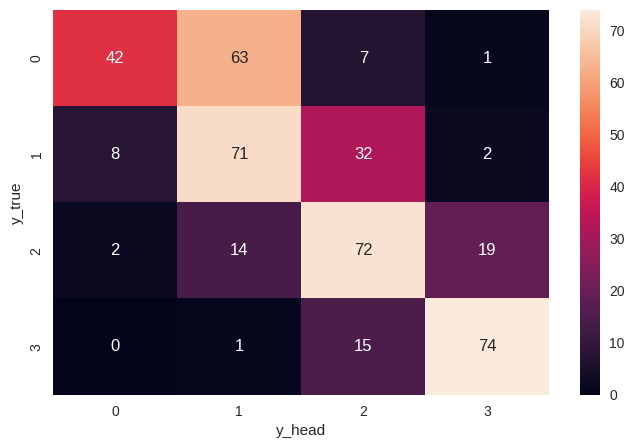

In [82]:
f, ax = plt.subplots(figsize=(8,5))
sns.heatmap(confusion_matrix(y_test, Adanb_preds), annot=True, fmt=".0f", ax=ax)
plt.xlabel("y_head")
plt.ylabel("y_true")
plt.show()

In [83]:
!pip install yellowbrick

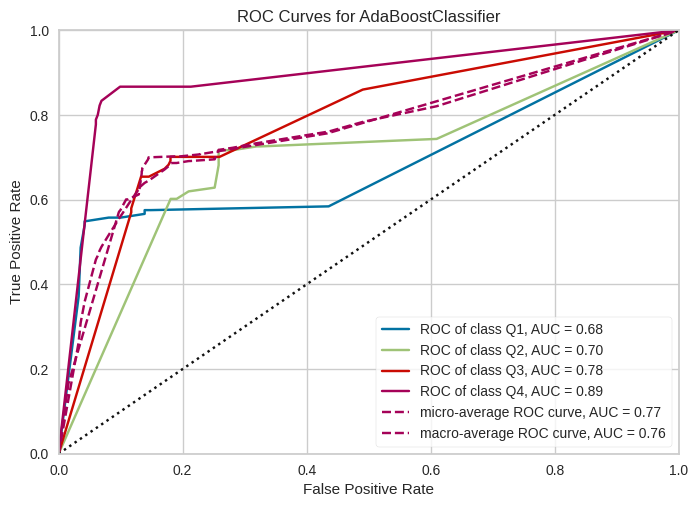

<Figure size 800x550 with 0 Axes>

In [84]:
from yellowbrick.classifier.rocauc import roc_auc
roc_auc(Adanb, X_train, y_train, X_test=X_test, y_test=y_test)
plt.savefig('roc_auc.png')